# Latent Dynamics Estimation on a Synthetic Generator
# 2.1. Synthetic generator on the two-sphere

In [2]:
import numpy as np
import matplotlib.pyplot as plt

Parameters

In [3]:
mu    = np.array([0,0,1])
kappa = 0.5
sigma = 0.2
dt    = 0.01
T     = 100
d     = 2

def simulate_ou_on_sphere(mu = np.array([0,0,1]),
                          kappa: float = 0.5,
                          sigma: float = 0.2,
                          dt:float = 0.01,
                          T: int = 100,
                          d: int = 2):
    
    # Generating the latent process Yt
    Y = np.zeros(shape=(T,d))
    Y[0] = np.random.multivariate_normal(mean=np.zeros(d), cov=np.eye(d))

    for t in range(1,T):
        xi = np.random.multivariate_normal(mean=np.zeros(d), cov=(np.eye(d)))
        Y[t] = Y[t-1] - kappa * Y[t-1] * dt + sigma * np.sqrt(dt) * xi

    # Projecting onto the sphere with the exponential map
    X = np.zeros(shape=(T, d+1))

    Y_norm = np.linalg.norm(Y, axis=1)

    X[:,0] = (np.sin(Y_norm)/Y_norm) * Y[:,0]
    X[:,1] = (np.sin(Y_norm)/Y_norm) * Y[:,1]
    X[:,2] = np.cos(Y_norm)

    return X, Y

X, Y = simulate_ou_on_sphere()


In [4]:
%matplotlib widget

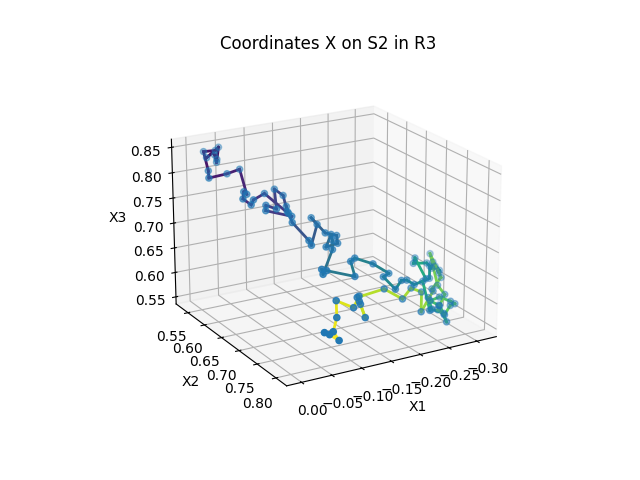

In [5]:
fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')
pts = np.column_stack((X[:, 0], X[:, 2], X[:, 1]))
cmap = plt.cm.viridis
norm = plt.Normalize(0, len(pts) - 2)

for i in range(len(pts) - 1):
    ax.plot(
        pts[i:i+2, 0],
        pts[i:i+2, 1],
        pts[i:i+2, 2],
        color=cmap(norm(i)),
        linewidth=2,
    )
ax.scatter(X[:, 0], X[:, 2], X[:, 1], s=20)
ax.set_xlabel('X1')
ax.set_ylabel('X2')
ax.set_zlabel('X3')
ax.set_title('Coordinates X on S2 in R3')
ax.view_init(elev=20, azim=60)
plt.show()

# 2.2.  Construction of the noisy high-dimensional observation

In [6]:
# D in [50, 100]
# sigma_eta in [0.05, 0.1, 0.2]
D = 50
sigma_eta = 0.1

def embed_with_noise(X, D=50, sigma_eta=0.1):
    T, d = X.shape

    # Generate random scalars b_j for j = 1, ..., D
    B = np.random.uniform(low=0, high=2*np.pi, size=D)
    # Generate the random vectors w_j in R^d for j = 1, ..., D
    W = np.random.multivariate_normal(mean=np.zeros(d), cov=np.eye(d), size=D)

    # g_j (x) = cos(wT_j x + b_j ) for j = 1, ..., D
    gX = np.cos((X @ W.T) + B)

    # Generate eta_t in R^D for t = 1, ..., T
    eta = np.random.multivariate_normal(mean=np.zeros(D), cov=sigma_eta**2*np.eye(D), size=T)

    # Get y_t for t = 1, ..., T by adding noise to gX
    Y = gX + eta

    return Y

Yt = embed_with_noise(X, D=50, sigma_eta=0.1)

### Showing that the first three coordinates of Yt don't look like OU process

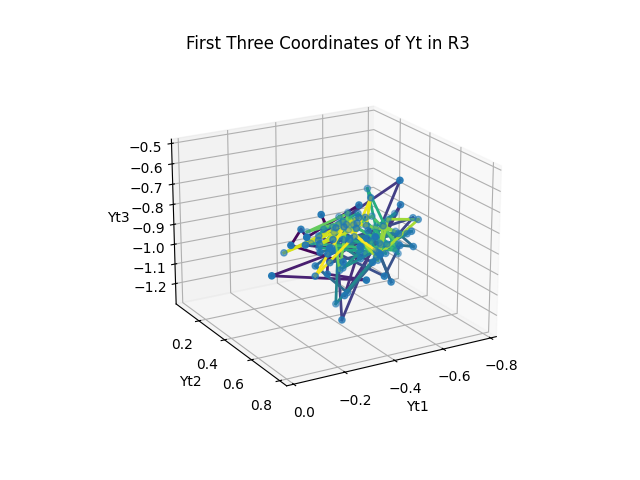

In [7]:
# Getting first three coordinates
Yt_cropped = Yt[:,:3]


fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')
pts = np.column_stack((Yt_cropped[:, 0], Yt_cropped[:, 2], Yt_cropped[:, 1]))
cmap = plt.cm.viridis
norm = plt.Normalize(0, len(pts) - 2)

for i in range(len(pts) - 1):
    ax.plot(
        pts[i:i+2, 0],
        pts[i:i+2, 1],
        pts[i:i+2, 2],
        color=cmap(norm(i)),
        linewidth=2,
    )
ax.scatter(Yt_cropped[:, 0], Yt_cropped[:, 2], Yt_cropped[:, 1], s=20)
ax.set_xlabel('Yt1')
ax.set_ylabel('Yt2')
ax.set_zlabel('Yt3')
ax.set_title('First Three Coordinates of Yt in R3')
ax.view_init(elev=20, azim=60)
plt.show()


This looks nothing like the plot on the sphere